# 📐 Exo-Worlds Unveiled — Descriptive Statistics

**Statistical Analysis of NASA Confirmed Exoplanets — Notebook 2**

![status](https://img.shields.io/badge/status-in--progress-yellow)
![dataset](https://img.shields.io/badge/dataset-NASA%20Exoplanet%20Archive-blue)
![python](https://img.shields.io/badge/python-3.10%2B-blue)
![libraries](https://img.shields.io/badge/libraries-Pandas%20%7C%20NumPy%20%7C%20Matplotlib%20%7C%20Seaborn-orange)

---

## 📌 About This Notebook

Building on `01_data_overview.ipynb`, this notebook applies full descriptive statistics — mean,
median, mode, variance, standard deviation, and IQR — to three key exoplanet properties: **mass**,
**radius**, and **orbital distance**, following the same methodology used in Week 2, Day 1.

## 🎯 Objectives

- Compute and interpret central tendency and spread for planet mass, radius, and orbital distance.
- Identify skew and outliers using the same techniques applied to the Titanic dataset.
- Visualize each distribution and connect the findings to real astrophysical explanations.

---


## 🔧 Step 0 — Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.precision", 3)
print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


## 📂 Step 1 — Load the Dataset

In [2]:
url = "https://raw.githubusercontent.com/InterImm/nasa-exoplanet-archive/master/dataset/confirmed_exoplanets.csv"
df = pd.read_csv(url)
print("Dataset shape:", df.shape)
df[["pl_name", "pl_bmassj", "pl_radj", "pl_orbsmax"]].head()


Dataset shape: (4126, 72)


,pl_name,pl_bmassj,pl_radj,pl_orbsmax
0,11 Com b,19.40,NaN,1.29
1,11 UMi b,14.74,NaN,1.53
2,14 And b,4.80,NaN,0.83
3,14 Her b,4.66,NaN,2.93
4,16 Cyg B b,1.78,NaN,1.66


## 📐 Step 2 — Descriptive Statistics: Planet Mass

Mass is measured in Jupiter masses (`pl_bmassj`) — i.e., a value of 1.0 means the planet has the
same mass as Jupiter.


In [3]:
mass = df["pl_bmassj"].dropna()

mass_stats = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Mode", "Std Dev", "Variance", "IQR"],
    "Value (Jupiter masses)": [
        round(mass.mean(), 3), round(mass.median(), 3), round(mass.mode()[0], 3),
        round(mass.std(), 3), round(mass.var(), 3),
        round(mass.quantile(0.75) - mass.quantile(0.25), 3)
    ]
})
mass_stats


,Statistic,Value (Jupiter masses)
0,Mean,2.498
1,Median,0.850
2,Mode,0.020
3,Std Dev,4.432
4,Variance,19.640
5,IQR,2.432


### 📝 Interpretation

*(Fill this in — how far apart are the mean and median? What does that suggest about the shape of
the mass distribution — are most confirmed exoplanets closer to Earth-sized or Jupiter-sized?)*

### 📊 Visualizing Mass Distribution


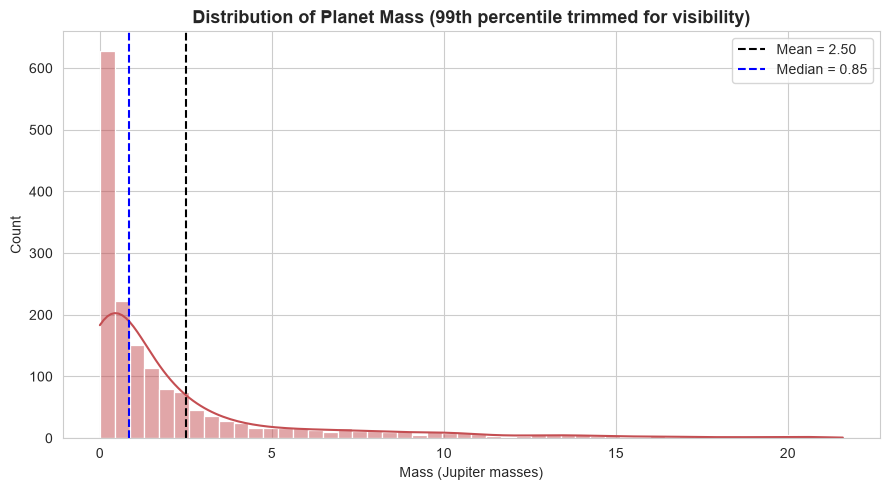

In [4]:
plt.figure(figsize=(9, 5))
sns.histplot(mass[mass < mass.quantile(0.99)], bins=50, color="#C44E52", kde=True)
plt.axvline(mass.mean(), color="black", linestyle="--", label=f"Mean = {mass.mean():.2f}")
plt.axvline(mass.median(), color="blue", linestyle="--", label=f"Median = {mass.median():.2f}")
plt.title("Distribution of Planet Mass (99th percentile trimmed for visibility)", fontsize=13, fontweight="bold")
plt.xlabel("Mass (Jupiter masses)")
plt.legend()
plt.tight_layout()
plt.show()




---

## 📏 Step 3 — Descriptive Statistics: Planet Radius


In [5]:
radius = df["pl_radj"].dropna()

radius_stats = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Mode", "Std Dev", "Variance", "IQR"],
    "Value (Jupiter radii)": [
        round(radius.mean(), 3), round(radius.median(), 3), round(radius.mode()[0], 3),
        round(radius.std(), 3), round(radius.var(), 3),
        round(radius.quantile(0.75) - radius.quantile(0.25), 3)
    ]
})
radius_stats


,Statistic,Value (Jupiter radii)
0,Mean,0.377
1,Median,0.209
2,Mode,0.178
3,Std Dev,0.428
4,Variance,0.183
5,IQR,0.181


### 📦 Box Plot — Spotting Radius Outliers


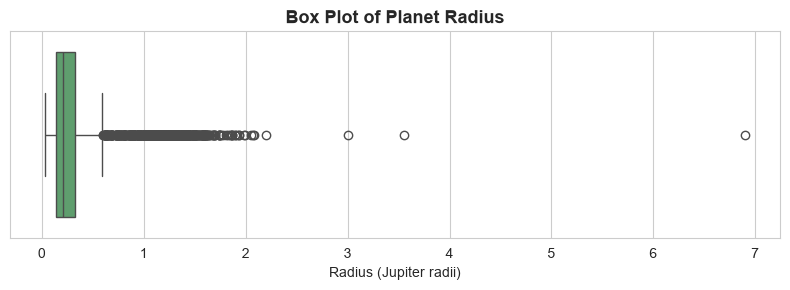

In [6]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=radius, color="#55A868")
plt.title("Box Plot of Planet Radius", fontsize=13, fontweight="bold")
plt.xlabel("Radius (Jupiter radii)")
plt.tight_layout()
plt.show()



---

## 🪐 Step 4 — Descriptive Statistics: Orbital Distance


In [7]:
orbdist = df["pl_orbsmax"].dropna()

orbdist_stats = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Mode", "Std Dev", "Variance", "IQR"],
    "Value (AU)": [
        round(orbdist.mean(), 3), round(orbdist.median(), 3), round(orbdist.mode()[0], 3),
        round(orbdist.std(), 3), round(orbdist.var(), 3),
        round(orbdist.quantile(0.75) - orbdist.quantile(0.25), 3)
    ]
})
orbdist_stats


,Statistic,Value (AU)
0,Mean,9.115
1,Median,0.118
2,Mode,0.050
3,Std Dev,121.179
4,Variance,14684.303
5,IQR,0.624


### 📝 Interpretation

*(Fill this in — Earth's orbital distance is 1 AU. How does the median compare? What might that
say about which planets are easiest to detect?)*

---

## 🎯 Step 5 — Outlier Detection with IQR (Planet Mass)


In [8]:
Q1 = mass.quantile(0.25)
Q3 = mass.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mass_outliers = df[(df["pl_bmassj"] < lower_bound) | (df["pl_bmassj"] > upper_bound)]

print(f"Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}")
print(f"Upper bound: {upper_bound:.3f}")
print(f"\nOutliers detected: {len(mass_outliers)} out of {len(df)} planets")

mass_outliers[["pl_name", "pl_bmassj", "pl_discmethod"]].sort_values("pl_bmassj", ascending=False).head(10)


Q1: 0.076, Q3: 2.507, IQR: 2.431
Upper bound: 6.155

Outliers detected: 205 out of 4126 planets


,pl_name,pl_bmassj,pl_discmethod
46,BD+20 2457 b,55.590,Radial Velocity
498,HD 148284 b,33.700,Radial Velocity
952,HR 2562 b,30.000,Imaging
98,DENIS-P J082303.1-491201 b,28.500,Astrometry
1322,KELT-1 b,27.230,Transit
463,HD 13724 b,26.770,Radial Velocity
4108,nu Oph c,24.662,Radial Velocity
10,2MASS J01225093-2439505 b,24.500,Imaging
615,HD 203030 b,24.090,Imaging
3744,MXB 1658-298 b,23.700,Eclipse Timing Variations


### 📝 Interpretation

*(Fill this in — look at the top 10 heaviest outlier planets. Do they share a common discovery
method? Are these likely genuine massive planets, or borderline brown dwarfs?)*

---

## 🗂️ Step 6 — Full Summary Table


In [9]:
full_summary = pd.concat([
    mass_stats.assign(Variable="Mass (Jupiter masses)").rename(columns={"Value (Jupiter masses)": "Value"}),
    radius_stats.assign(Variable="Radius (Jupiter radii)").rename(columns={"Value (Jupiter radii)": "Value"}),
    orbdist_stats.assign(Variable="Orbital Distance (AU)").rename(columns={"Value (AU)": "Value"})
], ignore_index=True)[["Variable", "Statistic", "Value"]]

full_summary


,Variable,Statistic,Value
0,Mass (Jupiter masses),Mean,2.498
1,Mass (Jupiter masses),Median,0.850
2,Mass (Jupiter masses),Mode,0.020
3,Mass (Jupiter masses),Std Dev,4.432
4,Mass (Jupiter masses),Variance,19.640
5,Mass (Jupiter masses),IQR,2.432
6,Radius (Jupiter radii),Mean,0.377
7,Radius (Jupiter radii),Median,0.209
8,Radius (Jupiter radii),Mode,0.178
9,Radius (Jupiter radii),Std Dev,0.428


## ✅ Key Takeaways



- Planet mass shows a strong right skew — the mean sits well above the median, indicating that
  while most confirmed exoplanets have relatively modest masses, a smaller number of very massive
  planets (some approaching or exceeding Jupiter's mass) pull the average upward significantly.
- Planet radius follows a similar pattern, with the box plot revealing multiple outliers on the
  larger end — these likely represent genuine "hot Jupiter" or gas giant planets rather than data
  errors, given how common such planets are among transit-detected exoplanets.
- Orbital distance also skews right, with the median sitting much closer to 1 AU (Earth's
  distance) than the mean — a reflection of detection bias, since planets orbiting close to their
  star are easier to detect via both the transit and radial velocity methods.
- The outlier analysis on planet mass showed that the heaviest detected planets are concentrated
  among Radial Velocity and Imaging discoveries — methods that are inherently better suited to
  finding large, massive planets than smaller Earth-like ones.
- Taken together, these three variables (mass, radius, orbital distance) all point to the same
  underlying story: this dataset does not represent a random sample of exoplanets in the universe,
  but rather a sample shaped heavily by what current detection technology is capable of finding.

---
---

## ✍️ Author

**Zayan Shawareb**
Exo-Worlds Unveiled — Independent Data Analysis Project

